In [533]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
from pathlib import Path
path = Path.cwd() / "01_przetwarzanie_wizualizacja_danych" / "titanic.csv"
titanic_df = pd.read_csv(path, index_col='PassengerId')
titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


path moze nieprofesjonalnie ale jakos inaczej mi nie moglo zadzialac

zanim zaczne cokolwiek sprawdzać zamienie sobie zmienną Sex na kodowanie liczbowe

Najpierw sprawdzmy czy faktycznie mamy tylko wartości male oraz female

In [534]:
titanic_df["Sex"].unique()


<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

Dobra odziwo tutaj twórca datasetu się postarał, teraz można bez większego trudu zakodować to binarnie

In [535]:
titanic_df["Sex"] = titanic_df["Sex"] == "female"
titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",False,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",True,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",True,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",True,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",False,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",False,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",True,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",True,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [536]:
titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,793.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,33.123938
std,0.486592,0.836071,14.526497,1.102743,0.806057,51.578312
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.500000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.275000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


martwią mnie dosyć liczby ułamkowe w kolumnie Age po za tym wszystko wydaje się być okej

In [537]:
titanic_df["Age"].sort_values()

PassengerId
804    0.42
756    0.67
645    0.75
470    0.75
79     0.83
       ... 
860     NaN
864     NaN
869     NaN
879     NaN
889     NaN
Name: Age, Length: 891, dtype: float64

Widzimy że faktycznie wartości ułamkowe występują co ma sens dla dzieci poniżej 2 lat(wiek podawany w miesiącach) sprawdźmy czy ta sytuacja nie ma miejsca w wieku powyżej 2 lat

In [538]:
int_mask = titanic_df["Age"] % 1 != 0
titanic_df.loc[int_mask, "Age"].sort_values()

PassengerId
804    0.42
756    0.67
470    0.75
645    0.75
832    0.83
       ... 
860     NaN
864     NaN
869     NaN
879     NaN
889     NaN
Name: Age, Length: 202, dtype: float64

Widzimy że powyżej 1 roku życia ta sytuacja wypada rzadko(jest to troche dziwne że ktoś mając 20 lat wpisał że ma 20 i pół niewiem z czego to wynika ale wątpie że ma to wpływ na przeżywalność)

## Sprawdźmy sobie brakujące dane

In [539]:
def na_check(df):
    na_mask = df.isna()
    print(na_mask.sum().reset_index(name='na_count'))
na_check(titanic_df)

       index  na_count
0   Survived         0
1     Pclass         0
2       Name         0
3        Sex         0
4        Age       177
5      SibSp         0
6      Parch         0
7     Ticket         0
8       Fare        98
9      Cabin       687
10  Embarked         2


# Obsługa NaN/Null
### Lista kolumn zawierających NaN/Null:
- Age
- Fare
- Cabin

### Age - 177 brakujących pozycji
Niewydaje mi się żeby brak wieku wskazywał nam żadnych dodatkowych informacji, teorytycznie pewnie dałoby się wiek odtworzyć na bazie numeru biletu/imienia ale to bym musiał miec dostęp do jakichś pełniejszych danych.

Nie chciałbym usuwać 177 wierszy tylko dlatego że mamy NaN w Age, natomiast wiek był czynnikiem mocno decydującym o tym czy ktoś przeżył, w końcu najpierw kobiety i DZIECI dlatego nie podoba mi się idea zastąpienia danych średnią czy też nawet random.choice z rozkładu.

### Fare - 98 brakujących pozycji
Brak informacji o cenie biletu może wskazywać na to że np. cena była niestandardowa (może bilet był z jakiejś promocji)

Szczerze przemyślałbym czy nie opłaca się usunąć tej kolumny, okej cena biletu wpływa na przeżywalność pasażera ale wydaje mi się że jest to wpływ pośredni, cena powinna być mocno skorelowana klasą podróży która powinna mieć nadrzędne znaczenie, sprawdzę na ile te cechy są skorelowane i podejmę decyzje.


### Cabin - 687 brakujących pozycji
tutaj brak podanej informacji o kabinie jest informacją samą w sobie, jeżeli w miejscu Cabin mamy NaN najprawdopodobniej wskazuje to na to że pasażer nie miał swojej kabiny

tutaj decyzja pada na dodanie zmiennej "Unknown"

# Sprawdzenie Korelacji
### Zrobimy sobie macierz korelacji
Dzieki temu dowemy się czy niektórych kolumn nie opłaca się może usunąć

In [540]:
#Pożyczam/modyfikuje
def plot_correlation_matrix(df, row=None):
    """
    Plots a heatmap showing the correlation matrix for numeric columns in the DataFrame.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing numeric data.
    Returns:
        None. Displays the correlation heatmap.
    """
    # compute correlation matrix only for numeric columns
    corr = df.corr(numeric_only=True)

    # fmt=".2f" rounds the number to 0.01
    plt.figure(figsize=(10, 8))
    if row:
        sns.heatmap(corr.loc[[row]], annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, square=True, cbar=False)
    else:
        sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

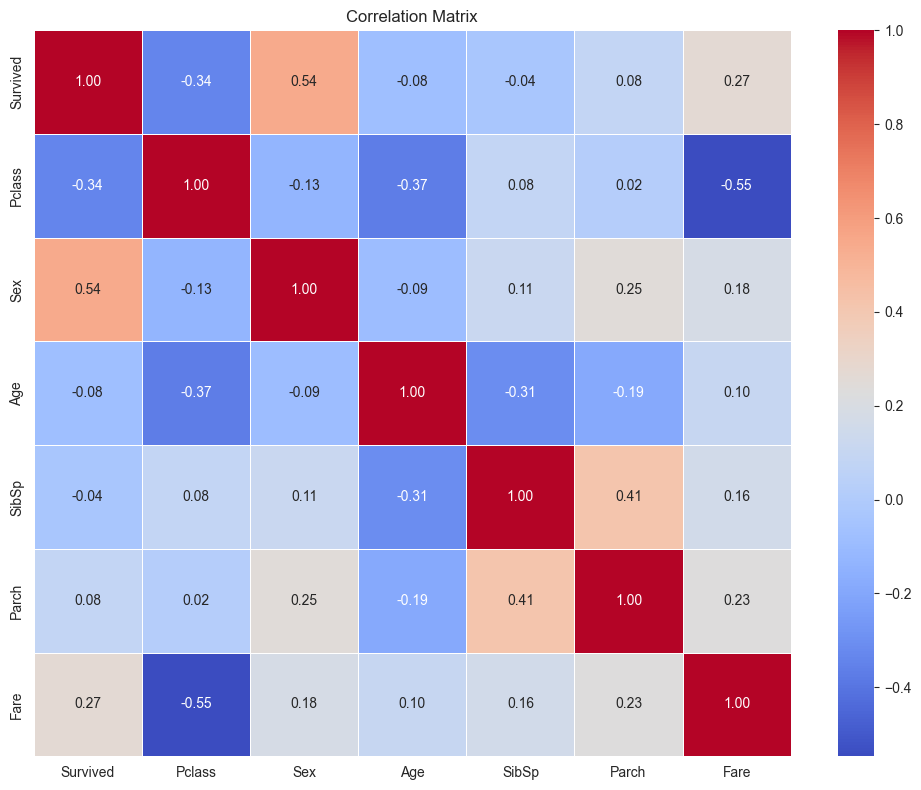

In [541]:
corr_df = titanic_df
plot_correlation_matrix(corr_df)

# Wyniki korelacji
Widzimy że nic nie jest ze sobą mocno skorelowane najmocniejsza korelacje możemy zauważyć między klasą a ceną biletu(korelacja jest ujemna bo im "mniejsza" klasa tym większa cena biletu) oraz płeć.

Jeżeli chodzi o nierozwiązany problem age najchętniej zrobiłbym jakiegoś typu regresje żeby jak najdokładniej spróbować przewidzieć w jakim wieku był dany pasażer, natomiast z racji że jeszcze się tego nie uczyliśmy i nie przerabialiśmy to na potrzeby dydaktyczne dolosuje brakujeące wartości z rozkładu

Dodatkowo utworzę zmienna Has_age żeby może uzbierać jakieś dodatkowe informacje

In [542]:
age_distribution = titanic_df["Age"].value_counts(normalize=True)
age_distribution

Age
24.00    0.042017
22.00    0.037815
18.00    0.036415
28.00    0.035014
19.00    0.035014
           ...   
24.50    0.001401
0.67     0.001401
0.42     0.001401
34.50    0.001401
74.00    0.001401
Name: proportion, Length: 88, dtype: float64

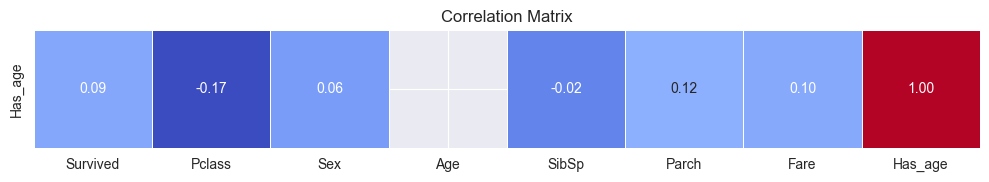

In [543]:
titanic_df[["Has_age"]] = ~titanic_df[["Age"]].isna()

plot_correlation_matrix(titanic_df, "Has_age")

Widzimy że Has_age ma jakąś kotelacje z Survived więc można zostawić(możnaby było to uzasadniać tym że dla osób które kupiły tańsze bilety dane były spisywane mniej skrupulatnie)

In [544]:
age_values = age_distribution.index
age_probs = age_distribution.values

missing_age = titanic_df["Age"].isna()
titanic_df.loc[missing_age, "Age"] = np.random.choice(age_values, size=missing_age.sum(), p=age_probs)



chciałbym docenic że prawie wszystko było już zakodowane liczbowo, natomiast większość która zakodowana nie była:
- Imię
- Nr biletu
- Embarked

możemy śmiało usunąć może byłyby skorelowane z Przeżywalnością, natomiast nie chciałbym tu nadinterpretować oraz mylić korelacji z przyczynowością(na logike żadna z tych cech nie może mieć bezpośredniego wpływu na przeżywalność, także uznaje je za niepotrzebny szum)

## PO REVIEW
- z numeru biletu chcę wyciągnąć zmienną TicketSize (do policzenia isAlone)
- chcę posortować porty z embarked od najbiedniejszego do najbogatszego i zakodować liczbowo(sprawdze potem korelacje czy takie podejscie faktycznie pomogło)



In [545]:
titanic_df = titanic_df.drop("Name", axis=1)
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_age
PassengerId,,,,,,,,,,,
1,0,3,False,22.0,1,0,A/5 21171,7.2500,NaN,S,True
2,1,1,True,38.0,1,0,PC 17599,71.2833,C85,C,True
3,1,3,True,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True
4,1,1,True,35.0,1,0,113803,53.1000,C123,S,True
5,0,3,False,35.0,0,0,373450,8.0500,NaN,S,True
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,False,27.0,0,0,211536,13.0000,NaN,S,True
888,1,1,True,19.0,0,0,112053,30.0000,B42,S,True
889,0,3,True,23.0,1,2,W./C. 6607,23.4500,NaN,S,False


In [546]:
TicketSize = titanic_df["Ticket"].value_counts()
titanic_df["TicketSize"] = titanic_df["Ticket"].map(TicketSize)
titanic_df = titanic_df.drop("Ticket", axis=1)
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Has_age,TicketSize
PassengerId,,,,,,,,,,,
1,0,3,False,22.0,1,0,7.2500,NaN,S,True,1
2,1,1,True,38.0,1,0,71.2833,C85,C,True,1
3,1,3,True,26.0,0,0,7.9250,NaN,S,True,1
4,1,1,True,35.0,1,0,53.1000,C123,S,True,2
5,0,3,False,35.0,0,0,8.0500,NaN,S,True,1
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,False,27.0,0,0,13.0000,NaN,S,True,1
888,1,1,True,19.0,0,0,30.0000,B42,S,True,1
889,0,3,True,23.0,1,2,23.4500,NaN,S,False,2


In [547]:
titanic_df.dropna(subset="Embarked", inplace=True)

embarkedy = titanic_df.groupby("Embarked")["Pclass"]
embarkedy.mean()


Embarked
C    1.886905
Q    2.909091
S    2.350932
Name: Pclass, dtype: float64

I teraz po tym zrobimy sobie kodowanie:
- Q:1
- S:2
- C:3
im większy tym z bogatszej klasy społecznej

In [548]:
titanic_df["Embarked"] = titanic_df["Embarked"].map({"Q":1, "S":2, "C":3})


elementy które trzeba zakodować:
- Cabin


Moim pomysłem na Cabin jest zamiana na zmienna Has_Cabin gdzie 1 to informacja że kabina była podana a 0 to informacja że Kabiny podanej nie było spróbujmy to zakodować i wyświetlić korelacje has_cabin z Survived żeby sprawdzić czy ten pomysł ma sens

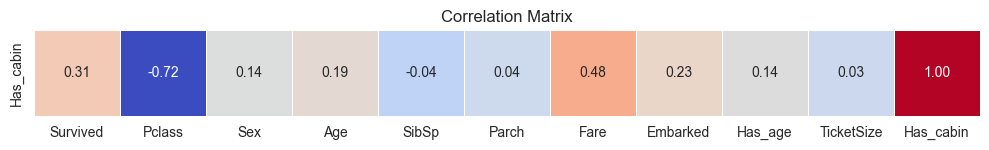

In [549]:
titanic_df[["Has_cabin"]] = ~titanic_df[["Cabin"]].isna()
titanic_df.drop("Cabin", axis=1, inplace=True)
plot_correlation_matrix(titanic_df, "Has_cabin")


Widzimy że nie tylko Has_cabin koreluje(prawie najmocniej) z survived ale również mocno koreluje z Pclass co oznacza że moja teza o tym że ktoś mógł nie mieć swojej kabiny powinna być prawdziwa.




## Co z kolumną fare?
Faktycznie jest mocno skorelowana z kolumną Pclass natomiast nie aż tak bardzo jak podejrzewałem, decyduje się zostawić tą kolumne a braki których jest niewiele zastąpie

Przedtym jednak utworze zmienną Has_fare i sprawdzę czy nie ma ona jakiejs korelacji z survived

## PO REVIEW
uzupełnienie braków medianą ale pogrupowaną względem Pclass

In [550]:
"""


#szybkie sprawdzenie czy dane są wyczyszczone
print(na_check(titanic_df))

print("===========================")

plot_correlation_matrix(titanic_df, "Has_fare")"""
titanic_df[["Has_fare"]] = ~titanic_df[["Fare"]].isna()
MedianByClass = titanic_df.groupby("Pclass")["Fare"].median()

titanic_df["Fare"] = titanic_df["Fare"].fillna(titanic_df["Pclass"].map(MedianByClass))
titanic_df


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_age,TicketSize,Has_cabin,Has_fare
PassengerId,,,,,,,,,,,,
1,0,3,False,22.0,1,0,7.2500,2,True,1,False,True
2,1,1,True,38.0,1,0,71.2833,3,True,1,True,True
3,1,3,True,26.0,0,0,7.9250,2,True,1,False,True
4,1,1,True,35.0,1,0,53.1000,2,True,2,True,True
5,0,3,False,35.0,0,0,8.0500,2,True,1,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,False,27.0,0,0,13.0000,2,True,1,False,True
888,1,1,True,19.0,0,0,30.0000,2,True,1,True,True
889,0,3,True,23.0,1,2,23.4500,2,False,2,False,True


jak widzimy Has_fare ma marginalne znaczenie więc żeby nie dodawać zbędnego szumu usunę tą kolumne

In [551]:
titanic_df.drop("Has_fare", axis=1, inplace=True)


# sprawdzanie outlierów

### Wydaje mi się że najłatwiej będzie to zrobić boxplotem

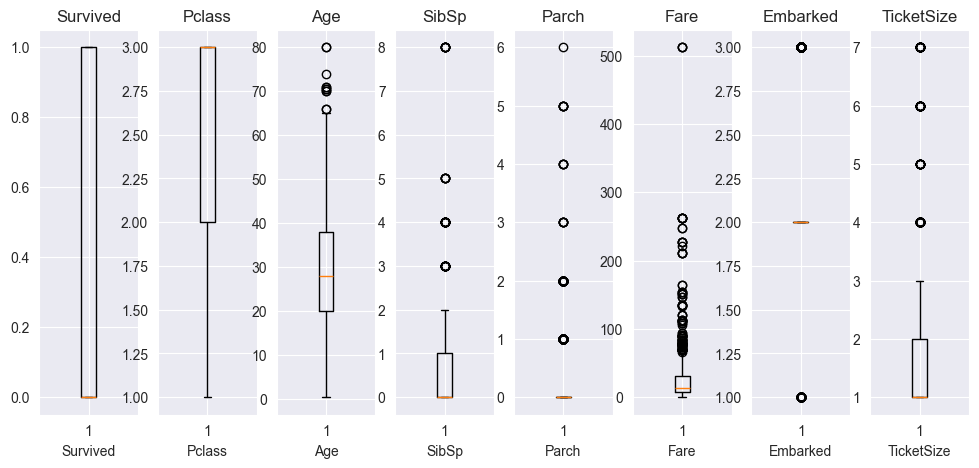

In [552]:
numeric_cols = titanic_df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(12, 5))
for i,name in enumerate(numeric_cols):
    plt.subplot(1, len(numeric_cols), i+1)
    plt.boxplot(titanic_df[[name]])
    plt.title(name)
    plt.xlabel(name)



jeżeli chodzi o otliery to nie widzę nic podejrzanego outliery wystepują dla:
- Age (pare przypadków lekko ponad norme, wydaje się być okej)
- SibSP/Parch (tutaj outliery wskazują na to że po prostu większość pasażerów wypłyneła w pojedynke)
- Fare (łatwo  mi jest uwieżyć w to że są jednostki które wydały znacznie więcej na bilet niż większość)


# Podsumowując

### Zbiór został wyczyszczony

### Zbiór ma 2 dodatkowe kolumny wzbogacające dane:
- Has_cabin
- Has_Age

### Cechy kategorialne są zakodowane liczbowo:
- Większość usunąłem
- Cabin zamieniłem na Has_cabin
- Pclass zostawiłem tak jak jest bo jak najbardziej klasa 1 jest lepsza od np 2 czy 3 (możnaby było myśleć o obróceniu kolejności ale model sobie z tym raczej poradzi)
- zmienna o płci zamieniłem na kodowaną binarnie(1-kobieta, 0-mężczyzna)
### Wizualizacja
- Zwizualizowałem większość cech(szukanie outlierów)
- Pokazałem korelacje miedzy każdą cechą


# Poprawki po cross review

od teraz pojawiaja sie poprawki/zmiany
jeżeli coś wcześniej wymaga zmiany oznacze to stwierdzneiem:
### PO REVIEW

## Dodanie klas:
- isAlone (Z uwzględnieniem ticket size)
- AgeCat (kategoria wiekowa)

In [553]:
titanic_df["FamilyAndFriends"] = titanic_df["SibSp"] + titanic_df["Parch"] + titanic_df["TicketSize"]
titanic_df["isAlone"] = titanic_df["FamilyAndFriends"].map(lambda x: 1 if x<=1 else 0)


In [554]:
bins = [0, 12, 18, 35, 60, 100]
labels = [1,2,3,4,5]

titanic_df['AgeCat'] = pd.cut(titanic_df['Age'], bins=bins, labels=labels).astype(int)

sprawdżmy korelacje i pozbądźmy się cech z bardzo małą korelacją z kolumna survived

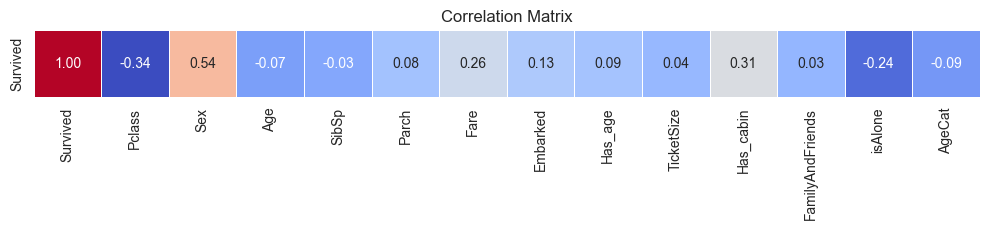

In [555]:
plot_correlation_matrix(titanic_df, "Survived")

no i widzimy że kolumny SibSp,TicketSize,FamilyAndFriends oraz Parch (z których wyciągneliśmy kluczową informacje - IsAlone) pojedyńczo dają nam ektremalnie mało informacji więc wypadałoby je usunąć


In [556]:
titanic_df = titanic_df.drop(["SibSp", "Parch", "TicketSize", "FamilyAndFriends"], axis=1)

wyswietlmy ogólną korelacje

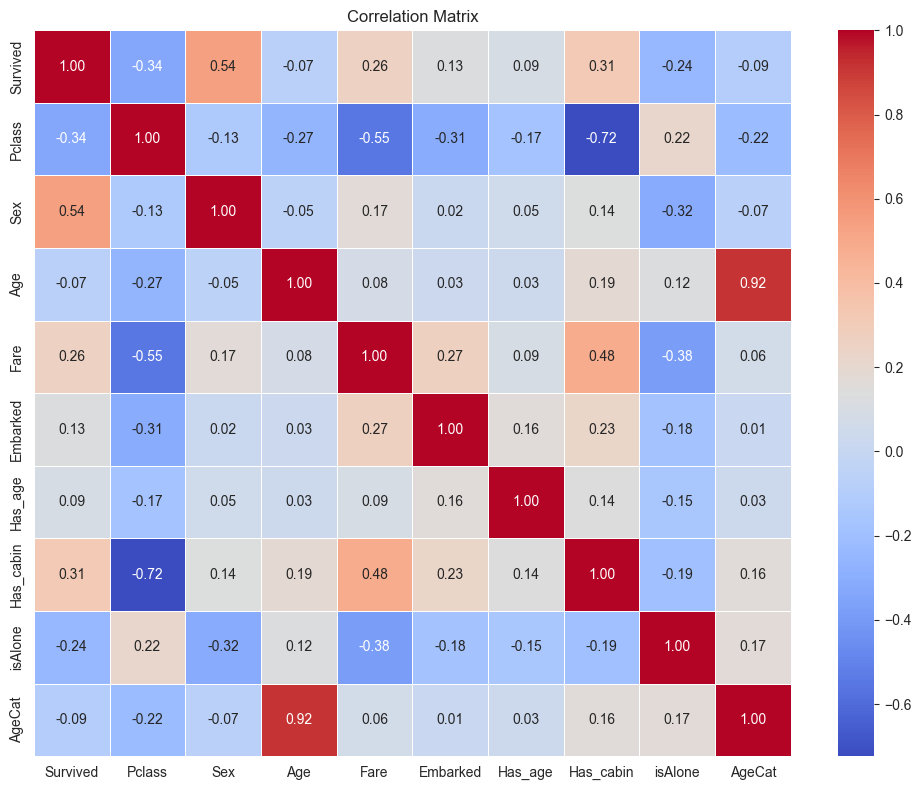

In [557]:
plot_correlation_matrix(titanic_df)

# Co dalej?
Trzeba:
- przeskalować dane
- zamienić survived na label

Pozwole sobie zrobić te rzeczy juz  w nowym pliku od zadania 2
